### Blog Writing Agent

In [1]:
# from __future__ import annotations is a special import in Python that changes how type hints (annotations) are handled.
# Normally, when you use type hints in Python, you need to ensure that any types you reference are defined before they are used. This can lead to issues when you want to reference a class that is not defined yet, such as in the case of a linked list where a node references another node of the same type.
# By importing annotations from the __future__ module, you can use type hints that reference classes that are defined later in the code. This allows for more flexible and readable type annotations, especially in cases like linked lists or recursive data structures.

# And this solves the future reference problem in the Node class where the next attribute is of type Node, which is not yet defined at the time of the annotation.

from __future__ import annotations
class Node:
    def __init__(self, next: Node | None = None):
        self.next = next

In [1]:
class Node:
    def __init__(self, next: Node | None = None):
        self.next = next

NameError: name 'Node' is not defined

In [4]:
# TypedDict - validating the data - Not
# Pydandic

from typing import TypedDict

class Student(TypedDict):
    name: str
    age: int
    
Student({"name":"Anant","age":"45"})

{'name': 'Anant', 'age': '45'}

In [9]:
from pydantic import BaseModel, Field

class Student(BaseModel):
    name: str
    age: int
    
Student({"name":"Anant","age":45})

TypeError: BaseModel.__init__() takes 1 positional argument but 2 were given

In [2]:
# Importing Dependency
from __future__ import annotations 

from pydantic import BaseModel, Field
from typing import TypedDict, List, Annotated
import operator

from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.types import Send
from pathlib import Path

from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

import warnings
warnings.filterwarnings("ignore")

e:\Agents_Langgraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# State Schema: Task State

class Task(BaseModel):
    id: int 
    title: str 
    brief: str = Field(..., description="What to cover")

In [4]:
# Plan Schema: Plan State
# Orchestrator - Planning node - will take topic and plan/break it down into sub-tasks

class Plan(BaseModel):
    blog_title: str 
    tasks: List[Task]

In [5]:
# Definig the state schema for the agent. 
# This will be used to store the state of the agent and the tasks it needs to perform.

class AgentState(TypedDict):
    topic: str 
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str 

In [6]:
# LLM Integration

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model = "llama-3.3-70b-versatile",
    temperature=0.3
)

In [9]:
# Orchestrator Node

def orchestrator(state: AgentState) -> dict:
    
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=("Create a blog plan with 5-7 sections based on the following topic")
            ),
            HumanMessage(content=f"Topic:{state['topic']}")
        ]
    )
    
    return {"plan":plan}

In [13]:
def fanout(state: AgentState):
    return [
        Send("worker", 
             {"task": task, 
              "topic": state["topic"], 
              "plan": state["plan"]
              }
             ) 
        for task in state["plan"].tasks]

Dynamic parallelism via the Send() API is the "superpower" of LangGraph. It moves you away from rigid, pre-defined flowcharts and toward elastic architectures that expand or contract based on the complexity of the input.

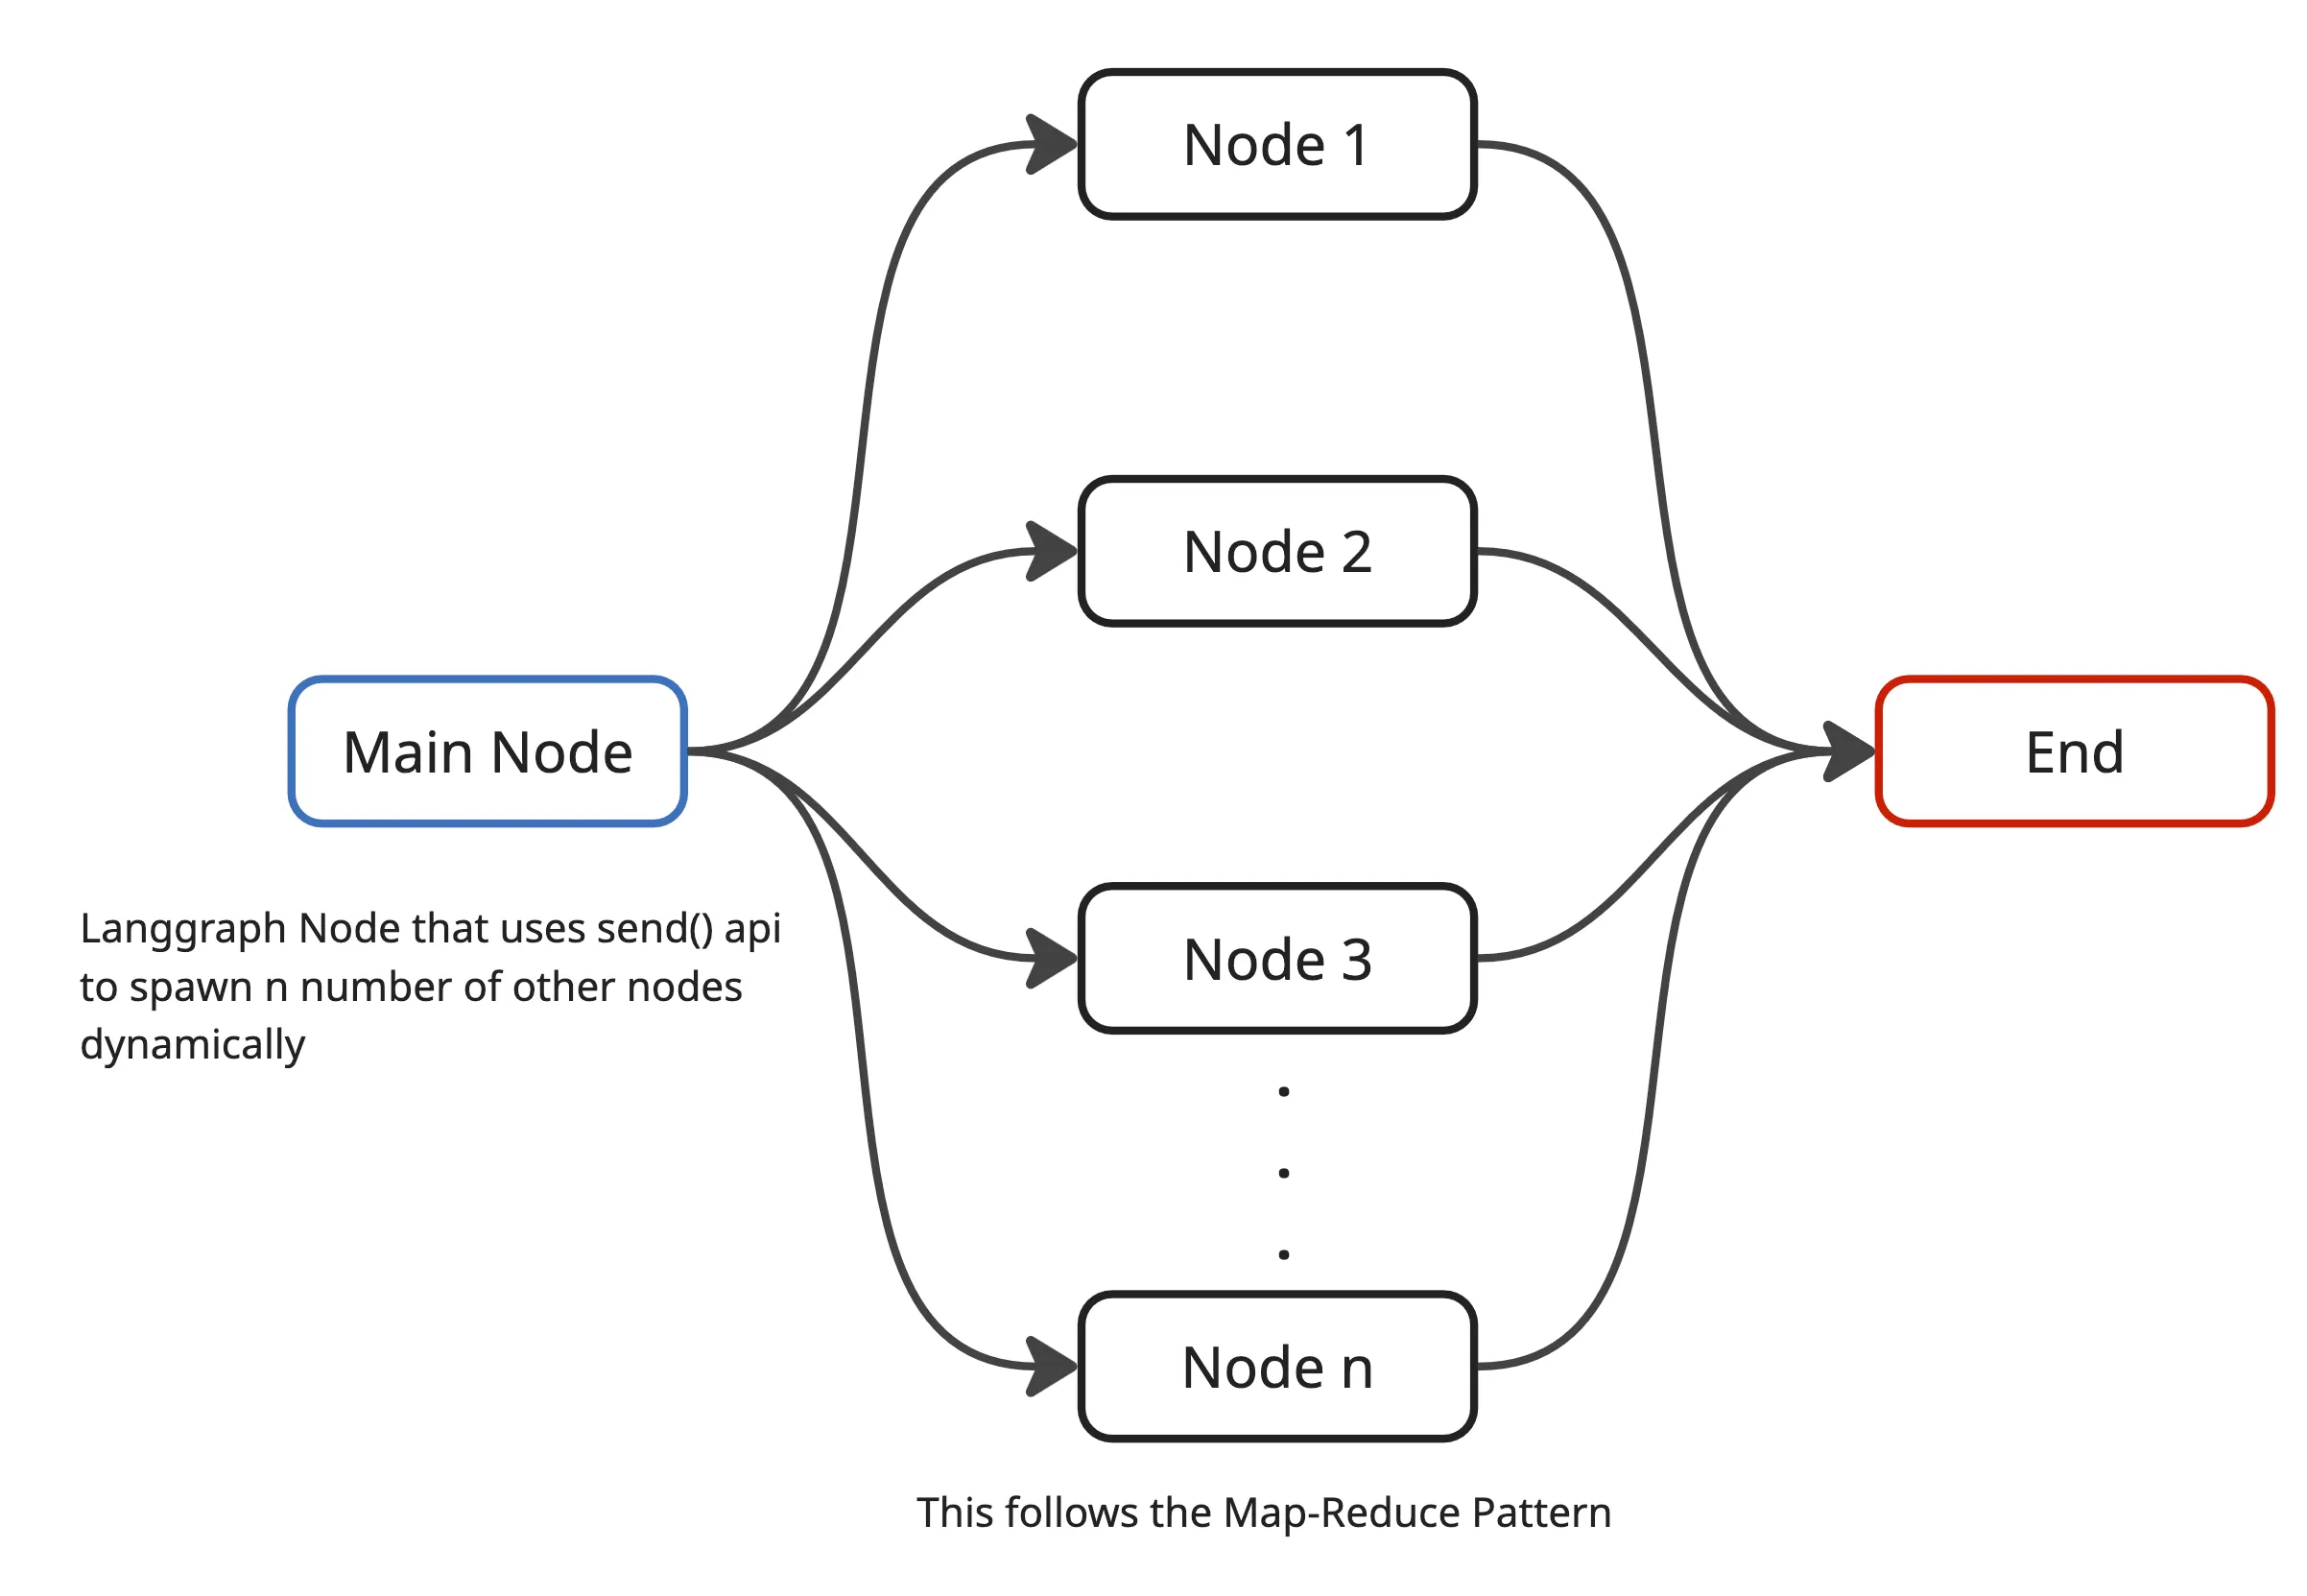

In [10]:
# Defining the worker function/node that will be executed for each task. 
# This function will take the task, topic, and plan as input and 
# return the section of the blog post for that task.

def worker(payload: dict) -> dict:
    
    # payload that we will send to the worker by the orchestrator
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]
    
    blog_title = plan.blog_title
    
    section_md = llm.invoke([
        SystemMessage(content="Write a one clean Markdown section"),
        HumanMessage(
            content=(
                f"Blog: {blog_title}\n"
                f"Topic: {topic}\n\n"
                f"Section: {task.title}\n"
                f"Brief: {task.brief}\n\n"
                "Return only the section content in Markdown."))
    ]).content.strip()
    
    return {"sections": [section_md]}

In [11]:
# Defining reducer function that will stiches the secctions together to form final blog post.

def reducer(state: AgentState) -> dict:
    
    title = state["plan"].blog_title
    
    body = "\n\n".join(state["sections"]).strip()
    
    final_blog = f"#{title}\n\n{body}\n"
    
    file_name = title.lower().replace(" ", "_") + ".md"
    
    output_path = Path(file_name)
    
    output_path.write_text(final_blog, encoding="utf-8")
    
    return {"final_blog": final_blog}

In [14]:
# Building the agent worlflow using the defined functions. The workflow will consist of the orchestrator, fanout, worker, and reducer functions.

workflow_builder = StateGraph(AgentState)

workflow_builder.add_node("orchestrator", orchestrator)
workflow_builder.add_node("worker", worker)
workflow_builder.add_node("reducer", reducer)

workflow_builder.add_edge(START, "orchestrator")
workflow_builder.add_conditional_edges("orchestrator", fanout, ["worker"])
workflow_builder.add_edge("worker", "reducer")
workflow_builder.add_edge("reducer", END)

workflow = workflow_builder.compile()

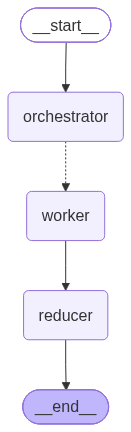

In [15]:
display(Image(workflow.get_graph().draw_mermaid_png()))

In [16]:
# Test the workflow by providing a topic for the blog post. The agent will generate a plan, execute the tasks, and produce the final blog post.

out = workflow.invoke({"topic": "Convolutional Neural Network."})

In [ ]:
print("Output\n\n", out)

In [ ]:
print(out["plan"])